In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, classification_report

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

import joblib
import os

In [3]:
df = pd.read_csv("../data/ev_battery_degradation_v1.csv")

df.head()

,Vehicle_ID,Car_Model,Battery_Type,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Driving_Style,Internal_Resistance_Ohm,SoH_Percent,Battery_Status
0,1fb46ae8,Tesla Model 3,NMC,75.0,41,390,21.5,0.51,2.22,Aggressive,0.0362,94.60,Healthy
1,b7ef35aa,Tesla Model 3,NMC,75.0,29,401,18.0,0.62,1.34,Aggressive,0.0333,95.68,Healthy
2,76cb49e0,Ford Mustang Mach-E,NMC,88.0,71,941,18.4,0.78,1.48,Conservative,0.0526,89.80,Healthy
3,456a7aef,Ford Mustang Mach-E,NMC,88.0,57,378,10.8,0.61,0.72,Moderate,0.0314,96.29,Healthy
4,bd758049,Tesla Model 3,NMC,75.0,58,239,30.3,0.89,1.48,Conservative,0.0297,96.75,Healthy


In [4]:
# remove duplicates
df = df.drop_duplicates()

# strip text columns
df["Battery_Type"] = df["Battery_Type"].str.strip()
df["Driving_Style"] = df["Driving_Style"].str.strip()
df["Battery_Status"] = df["Battery_Status"].str.strip()

# convert numeric columns
numeric_cols = [
    "Battery_Capacity_kWh",
    "Vehicle_Age_Months",
    "Total_Charging_Cycles",
    "Avg_Temperature_C",
    "Fast_Charge_Ratio",
    "Avg_Discharge_Rate_C",
    "Internal_Resistance_Ohm",
    "SoH_Percent"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# drop rows with missing values
df = df.dropna()

df.shape

(10000, 13)

In [5]:
df_model = df.copy()

# drop identifiers
df_model = df_model.drop(columns=["Vehicle_ID","Car_Model"])

# one hot encoding
df_model = pd.get_dummies(df_model, columns=["Battery_Type","Driving_Style"], drop_first=True)

df_model.head()

,Battery_Capacity_kWh,Vehicle_Age_Months,Total_Charging_Cycles,Avg_Temperature_C,Fast_Charge_Ratio,Avg_Discharge_Rate_C,Internal_Resistance_Ohm,SoH_Percent,Battery_Status,Battery_Type_NMC,Driving_Style_Conservative,Driving_Style_Moderate
0,75.0,41,390,21.5,0.51,2.22,0.0362,94.60,Healthy,True,False,False
1,75.0,29,401,18.0,0.62,1.34,0.0333,95.68,Healthy,True,False,False
2,88.0,71,941,18.4,0.78,1.48,0.0526,89.80,Healthy,True,True,False
3,88.0,57,378,10.8,0.61,0.72,0.0314,96.29,Healthy,True,False,True
4,75.0,58,239,30.3,0.89,1.48,0.0297,96.75,Healthy,True,True,False


In [6]:
X_reg = df_model.drop(columns=["SoH_Percent","Battery_Status"])
y_reg = df_model["SoH_Percent"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

In [8]:
reg_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

reg_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [9]:
y_pred = reg_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.3773099865527873
R2 Score: 0.9866107267714931


In [10]:
le = LabelEncoder()

df_model["Battery_Status_Label"] = le.fit_transform(df_model["Battery_Status"])

In [11]:
X_clf = df_model.drop(columns=["Battery_Status","Battery_Status_Label"])
y_clf = df_model["Battery_Status_Label"]

In [12]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [13]:
clf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

clf_model.fit(X_train_c, y_train_c)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [14]:
y_pred_c = clf_model.predict(X_test_c)

print(classification_report(y_test_c, y_pred_c))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



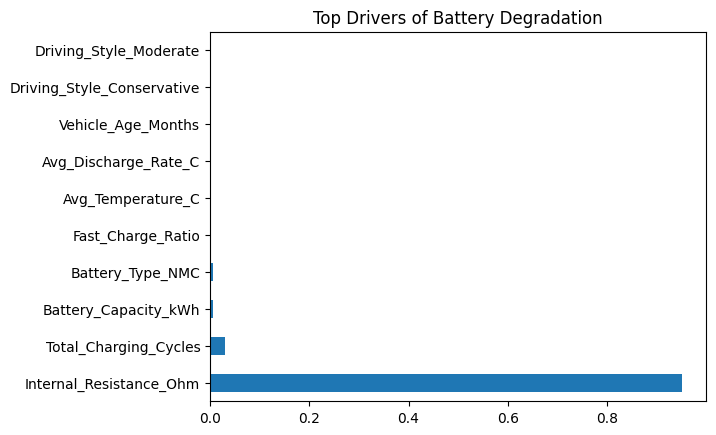

In [15]:
import matplotlib.pyplot as plt

importances = reg_model.feature_importances_
features = X_reg.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")

plt.title("Top Drivers of Battery Degradation")
plt.show()

In [16]:
os.makedirs("../artifacts/models", exist_ok=True)

joblib.dump(reg_model, "../artifacts/models/soh_regression_model.pkl")

joblib.dump(clf_model, "../artifacts/models/battery_failure_model.pkl")

joblib.dump(le, "../artifacts/models/status_encoder.pkl")

['../artifacts/models/status_encoder.pkl']

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import joblib, os

df = pd.read_csv("../data/ev_battery_degradation_v1.csv").drop_duplicates()

# basic cleaning
for c in ["Battery_Type","Driving_Style","Car_Model","Battery_Status"]:
    df[c] = df[c].astype("string").str.strip()

num_cols = [
    "Battery_Capacity_kWh","Vehicle_Age_Months","Total_Charging_Cycles",
    "Avg_Temperature_C","Fast_Charge_Ratio","Avg_Discharge_Rate_C","Internal_Resistance_Ohm"
]
for c in num_cols + ["SoH_Percent"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=num_cols + ["SoH_Percent","Battery_Status","Battery_Type","Driving_Style","Car_Model"])

# Features you will accept from Flask
FEATURES = num_cols + ["Battery_Type","Driving_Style","Car_Model"]

X = df[FEATURES]
y_reg = df["SoH_Percent"]
y_clf = df["Battery_Status"]

In [3]:
categorical_features = ["Battery_Type","Driving_Style","Car_Model"]
numeric_features = num_cols

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(n_estimators=250, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
reg_pipeline.fit(X_train, y_train)

pred = reg_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("REG RMSE:", rmse)
print("REG R2:", r2)

REG RMSE: 0.37593136444090314
REG R2: 0.9867083919610518


In [4]:
clf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=250, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)
clf_pipeline.fit(X_train, y_train)

pred = clf_pipeline.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      2000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [5]:
os.makedirs("../artifacts/models", exist_ok=True)

joblib.dump(reg_pipeline, "../artifacts/models/soh_reg_pipeline.pkl")
joblib.dump(clf_pipeline, "../artifacts/models/status_clf_pipeline.pkl")

print("✅ Saved pipelines to artifacts/models/")

✅ Saved pipelines to artifacts/models/
